# Resultados de optuna 

In [12]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast


In [13]:
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

In [14]:
data_dir = os.path.join("..", "output")
results = pd.read_csv(os.path.join(data_dir, "optuna_study_results.csv"))
top_10  = pd.read_csv(os.path.join(data_dir, "top_10_architectures_test_metrics.csv"))

In [18]:
# Pasarlas a excel
# Crear ruta de salida para guardar los Excel
output_dir = os.path.join(data_dir, "excel_exports")
os.makedirs(output_dir, exist_ok=True)

# Guardar como archivos Excel
results_path = os.path.join(output_dir, "resultados_optuna_completos.xlsx")
top_10_path = os.path.join(output_dir, "top_10_architecturas.xlsx")

results.to_excel(results_path, index=False)
top_10.to_excel(top_10_path, index=False)

print("✅ Archivos exportados exitosamente:")
print(f"- {results_path}")
print(f"- {top_10_path}")

✅ Archivos exportados exitosamente:
- ..\output\excel_exports\resultados_optuna_completos.xlsx
- ..\output\excel_exports\top_10_architecturas.xlsx


## Resultados de los 20 trials 

- Filas (trials): 20
- Columnas: 15
- Tipo de trial: COMPLETE o PRUNED (columna state)
- Métrica optimizada (value): corresponde al val_auc más alto alcanzado en cada trial
- Hiperparámetros explorados: hidden_channels, out_channels, num_heads, learning_rate, dropout_rate, activation_function, epochs, predictor_hidden_channels
- Métricas detalladas por epoch: están serializadas en user_attrs_best_val_auc_epoch_metrics

In [15]:
display(results.head())

,number,value,datetime_start,datetime_complete,duration,params_activation_function,params_dropout_rate,params_epochs,params_hidden_channels,params_learning_rate,params_num_heads,params_out_channels,params_predictor_hidden_channels,user_attrs_best_val_auc_epoch_metrics,state
0,0,0.942968,2025-07-25 17:04:32.391805,2025-07-25 17:20:19.286514,0 days 00:15:46.894709,tanh,0.106170,100,128,0.002607,4,32,64,"{'epoch_at_best_val_auc': 100, 'train_loss': 0...",COMPLETE
1,1,0.915718,2025-07-25 17:20:19.338854,2025-07-25 17:56:24.117957,0 days 00:36:04.779103,relu,0.303772,200,64,0.000251,8,32,64,"{'epoch_at_best_val_auc': 199, 'train_loss': 0...",COMPLETE
2,2,0.956588,2025-07-25 17:56:24.164814,2025-07-25 18:16:19.926574,0 days 00:19:55.761760,relu,0.260034,200,64,0.006586,4,64,64,"{'epoch_at_best_val_auc': 197, 'train_loss': 0...",COMPLETE
3,3,0.947219,2025-07-25 18:16:19.928728,2025-07-25 20:55:23.893231,0 days 02:39:03.964503,relu,0.140467,200,128,0.000599,8,64,64,"{'epoch_at_best_val_auc': 200, 'train_loss': 0...",COMPLETE
4,4,0.895780,2025-07-25 20:55:23.932300,2025-07-25 22:07:33.212203,0 days 01:12:09.279903,relu,0.311649,100,128,0.000141,8,128,128,"{'epoch_at_best_val_auc': 99, 'train_loss': 0....",COMPLETE


📊 Distribución de estados:
state
PRUNED      12
COMPLETE     8
Name: count, dtype: int64


C:\Users\Macarena Madrid\AppData\Local\Temp\ipykernel_10108\12007119.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results, x='state', palette='Set2')


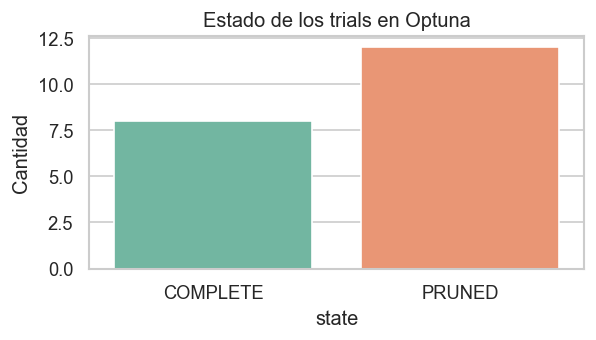

In [16]:
# Ver distribución de los estados
estado_counts = results['state'].value_counts()
print("📊 Distribución de estados:")
print(estado_counts)

# Mostrar como gráfico de barras
plt.figure(figsize=(5, 3))
sns.countplot(data=results, x='state', palette='Set2')
plt.title("Estado de los trials en Optuna")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()
